In [272]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle


In [42]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [43]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

shotnoise:  493.1632201614001
shotnoise:  290.6573669268956


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1499: RuntimeWarning: invalid value encountered in log10
  y3 = np.log10(y)


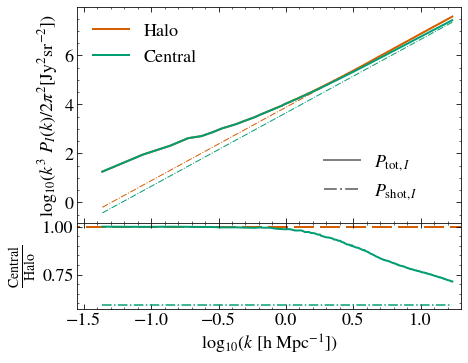

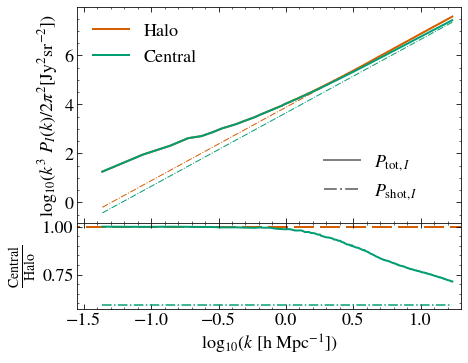

In [245]:
snapnum = 25
with open(f"{odir}/snap{snapnum}/mvir/ps-intensity-group_logM10.pickle", "rb") as f:
    Pk_mean_sum10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)


with open(f"{odir}/snap{snapnum}/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_cent10 = pickle.load(f)
    Pk_cent10 = pickle.load(f)

ps.compare_ps_plot([Pk_sum10, Pk_cent10], labels=["Halo", "Central"], ratio_ylabel_list=["Halo","Central"], bbox_to_anchor_grey=(0.6,0.4), bbox_to_anchor_color=(0,1), shotnoise_subtracted_ps=False, dots4group=True, color_list=palette_tab10[3:4] + palette_tab10[2:3] + palette_tab10[4:5], mean=[Pk_mean_sum10, Pk_mean_cent10])
#plt.savefig("../figures/cent_vs_halo_ps_jy.pdf", format="pdf", bbox_inches="tight")

In [122]:
z_list = [5, 4, 3, 2, 1.5,1,  0.4, 0.1, 0]

In [137]:
snap_list = [17, 21, 25,33, 40, 50, 72,91, 99]

In [240]:
from astropy.cosmology import Planck15
from astropy import units as u
mpc = 3.0856775814671914e24
h = 0.6774
def compute_intensity_factor(z):
    
    d_A_cm = Planck15.angular_diameter_distance(z).to(u.cm).value # proper angular diameter distance [cm]

    D_A = d_A_cm * (1+z) # comoving
    

    boxsize_mpc_h = 205
    
    boxsize_cm = boxsize_mpc_h * mpc / h
    boxsize_rad = boxsize_cm / (d_A_cm * (1+z))
    boxsize_deg = boxsize_rad / (2 * np.pi / 360)
    
    boxsize_deg = boxsize_deg*boxsize_deg
    boxsize_sr = boxsize_deg / (180/np.pi)**2 # convert from deg2 to sr
    
    
    

    lambda_rest = 6563e-8 # [cm]
    
    H = Planck15.H(z).to(u.Hz)

    l_l = Planck15.luminosity_distance(z).to(u.cm).value
    
    V = H.value * boxsize_sr * boxsize_cm / (lambda_rest * (1+z)**2) 
    
    return l_l**2 * V
    
    

In [228]:
def compute_intensity(mean_intensity, z):
    factor15 = compute_intensity_factor(z=1.5)
    
    factor_z = compute_intensity_factor(z=z)
    
    mean_intensity_z = mean_intensity * factor15/factor_z
    
    return mean_intensity_z
    

In [241]:

odir = "../ps_data"

ratio_list = []
intensity_list_group = []
intensity_list_cent = []

iend = 474

for i, snapnum in enumerate(snap_list):
    with open(f"{odir}/snap{snapnum}/mvir/ps-intensity-group_logM10.pickle", "rb") as f:
        Pk_mean_sum10 = pickle.load(f)
        Pk_sum10 = pickle.load(f)


    with open(f"{odir}/snap{snapnum}/mvir/ps-intensity-cent_logM10.pickle", "rb") as f:
        Pk_mean_cent10 = pickle.load(f)
        Pk_cent10 = pickle.load(f)
    
    k = Pk_cent10["k"][:iend]
    ratio = Pk_cent10["power"].real[:iend]/Pk_sum10["power"].real[:iend]
    
    ratio_list.append(ratio)
    
    intensity_group = compute_intensity(Pk_mean_sum10, z_list[i])
    
    intensity_cent = compute_intensity(Pk_mean_cent10, z_list[i])
    intensity_list_cent.append(intensity_cent)
    intensity_list_group.append(intensity_group)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in double_scalars
  from ipykernel import kernelapp as app
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:32: RuntimeWarning: invalid value encountered in double_scalars


shotnoise:  304.0903879154701
shotnoise:  201.65155090472237


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1500: RuntimeWarning: invalid value encountered in log10
  


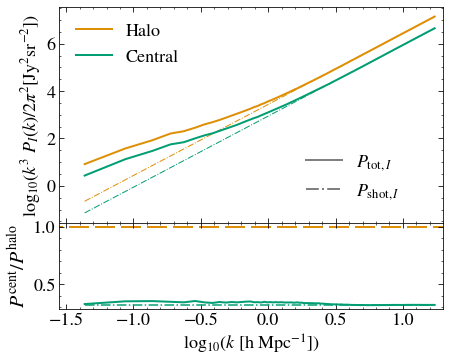

In [276]:
snapnum = 40
with open(f"{odir}/snap{snapnum}/mvir/ps-intensity-group_logM10.pickle", "rb") as f:
    Pk_mean_sum10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)


with open(f"{odir}/snap{snapnum}/mvir/ps-intensity-cent_logM10.pickle", "rb") as f:
    Pk_mean_cent10 = pickle.load(f)
    Pk_cent10 = pickle.load(f)

ps.compare_ps_plot([Pk_sum10, Pk_cent10], labels=["Halo", "Central"], ratio_ylabel="$P^{\mathrm{cent}}/P^{\mathrm{halo}}$", ratio_ylabel_list=["P^{halo}","P^{cent}"], bbox_to_anchor_grey=(0.6,0.4), bbox_to_anchor_color=(0,1), shotnoise_subtracted_ps=False, dots4group=True, color_list=palette_tab10[1:2] + palette_tab10[2:3] + palette_tab10[4:5], mean=[Pk_mean_sum10, Pk_mean_cent10])
#plt.savefig("../figures/cent_vs_halo_ps_jy.pdf", format="pdf", bbox_inches="tight")

In [242]:
cent_jy = np.array(intensity_list_cent)
group_jy = np.array(intensity_list_group)

In [175]:
cent_spherex = cent_jy / 10**17

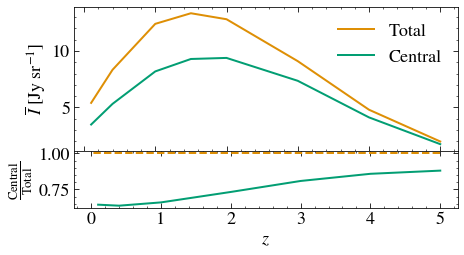

In [264]:
fig1 = plt.figure()
ax = fig1.add_axes((.15,.3,.8,.5))
plt.plot(z_list, group_jy, label="Total", c=palette_tab10[1])
plt.plot(z_list, cent_jy, label="Central", c=palette_tab10[2])

plt.ylabel(r"$\overline{I}\ [\mathrm{Jy\ sr}^{-1}]$")
plt.xlabel("z")
plt.legend()

frame2 = fig1.add_axes((.15,.1,.8,.2))
linewidth1=1
plt.plot([z_list[0],z_list[-1]],[1,1],  color=palette_tab10[1] , linestyle="dashed")
plt.plot(z_list, cent_jy/group_jy,color=palette_tab10[2])
plt.ylabel(r"$\frac{\mathrm{Central}}{\mathrm{Total}}$")
plt.xlabel("$z$")
#plt.savefig("../figures/cent_vs_tot_intensity.pdf", format="pdf", bbox_inches="tight")

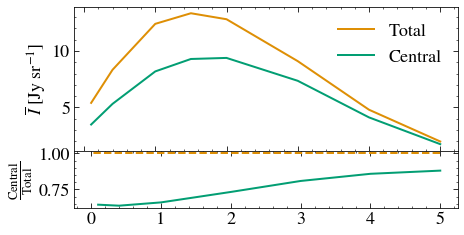

In [260]:
fig1 = plt.figure()
ax = fig1.add_axes((.15,.3,.8,.5))
plt.plot(z_list, group_jy, label="Total", c=palette_tab10[1])
plt.plot(z_list, cent_jy, label="Central", c=palette_tab10[2])

plt.ylabel(r"$\overline{I}\ [\mathrm{Jy\ sr}^{-1}]$")
plt.xlabel("z")
plt.legend()

frame2 = fig1.add_axes((.15,.1,.8,.2))
linewidth1=1
plt.plot([z_list[0],z_list[-1]],[1,1],  color=palette_tab10[1] , linestyle="dashed")
plt.plot(z_list, cent_jy/group_jy,color=palette_tab10[2])
plt.ylabel(r"$\frac{\mathrm{Central}}{\mathrm{Total}}$")
#plt.savefig("../figures/cent_vs_tot_intensity.pdf", format="pdf", bbox_inches="tight")

Text(0, 0.5, '$\\frac{\\mathrm{Central}}{\\mathrm{Total}}$')

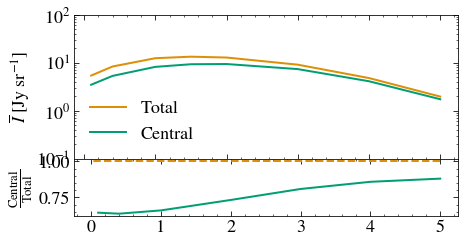

In [259]:
fig1 = plt.figure()
ax = fig1.add_axes((.15,.3,.8,.5))
plt.plot(z_list, group_jy, label="Total", c=palette_tab10[1])
plt.plot(z_list, cent_jy, label="Central", c=palette_tab10[2])

plt.ylabel(r"$\overline{I}\ [\mathrm{Jy\ sr}^{-1}]$")
plt.xlabel("z")
plt.legend()
plt.yscale("log")
plt.ylim(10**-1, 10**2)

frame2 = fig1.add_axes((.15,.1,.8,.2))
linewidth1=1
plt.plot([z_list[0],z_list[-1]],[1,1],  color=palette_tab10[1] , linestyle="dashed")
plt.plot(z_list, cent_jy/group_jy,color=palette_tab10[2])
plt.ylabel(r"$\frac{\mathrm{Central}}{\mathrm{Total}}$")

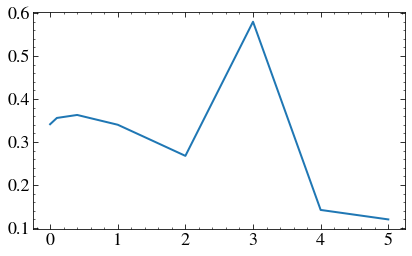

In [144]:
plt.plot(z_list, 1-cent_jy/group_jy)

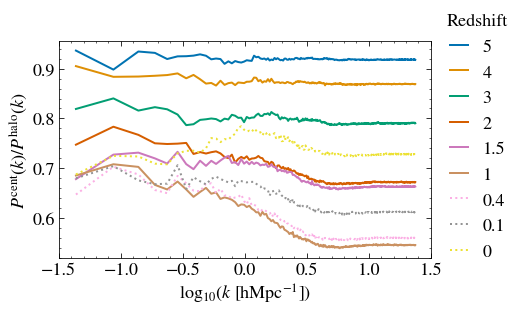

In [135]:
for i in range(0,6):
    plt.plot(np.log10(k), ratio_list[i], label=z_list[i], c=palette_tab10[i])
    
for i in range(6,9):
    plt.plot(np.log10(k), ratio_list[i], label=z_list[i], linestyle="dotted", c=palette_tab10[i])
    
plt.legend(loc="upper left", bbox_to_anchor=(1,1.2), title="Redshift", handlelength=1)
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
plt.ylabel("$P^{\mathrm{cent}}(k)/P^{\mathrm{halo}}(k)$")
plt.xlim(-1.5,1.5)
#plt.savefig("../figures/cent_vs_halo_ps_z.pdf", format="pdf", bbox_inches="tight")

(-1.55, 1.3)

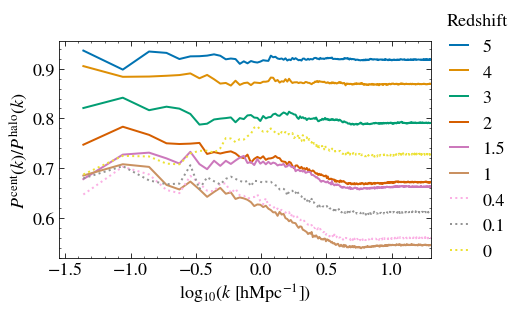

In [266]:
for i in range(0,6):
    plt.plot(np.log10(k), ratio_list[i], label=z_list[i], c=palette_tab10[i])
    
for i in range(6,9):
    plt.plot(np.log10(k), ratio_list[i], label=z_list[i], linestyle="dotted", c=palette_tab10[i])
    
plt.legend(loc="upper left", bbox_to_anchor=(1,1.2), title="Redshift", handlelength=1)
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
plt.ylabel("$P^{\mathrm{cent}}(k)/P^{\mathrm{halo}}(k)$")
plt.xlim(-1.55,1.3)
#plt.savefig("../figures/cent_vs_halo_ps_z.pdf", format="pdf", bbox_inches="tight")